In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, make_scorer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


RANDOM_STATE = 280926

In [ ]:
train = pd.read_csv("QSAR_challenge_train_80pct.csv")
test = pd.read_csv("QSAR_challenge_test_20pct_NO_TARGETS.csv")

In [12]:
print(train.info())
print(test.info())

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              623 non-null    str    
 1   nHM                    612 non-null    float64
 2   piPC09                 610 non-null    float64
 3   PCD                    616 non-null    float64
 4   X2Av                   611 non-null    float64
 5   MLOGP                  610 non-null    float64
 6   ON1V                   609 non-null    float64
 7   N-072                  604 non-null    float64
 8   B02[C-N]               616 non-null    float64
 9   F04[C-O]               607 non-null    float64
 10  regression_target      623 non-null    float64
 11  classification_target  623 non-null    int64  
dtypes: float64(10), int64(1), str(1)
memory usage: 58.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column     Non

In [14]:
feature_cols = [
    c for c in test.columns
    if c != "sample_id"]

reg_tafget = train["regression_target"]
cls_target = train["classification_target"]

In [15]:
feature_cols

['nHM',
 'piPC09',
 'PCD',
 'X2Av',
 'MLOGP',
 'ON1V',
 'N-072',
 'B02[C-N]',
 'F04[C-O]']

In [ ]:
# Imputation

from sklearn.experimental import enable_iterative_imputer  # Mandatory line
from sklearn.impute import IterativeImputer

X_train = train[feature_cols].copy()
X_test = test[feature_cols].copy()

im = IterativeImputer(random_state=RANDOM_STATE)
X_train_imputed = pd.DataFrame(im.fit_transform(X_train), columns=feature_cols)

X_test_imputed = pd.DataFrame(im.transform(X_test), columns=feature_cols)

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

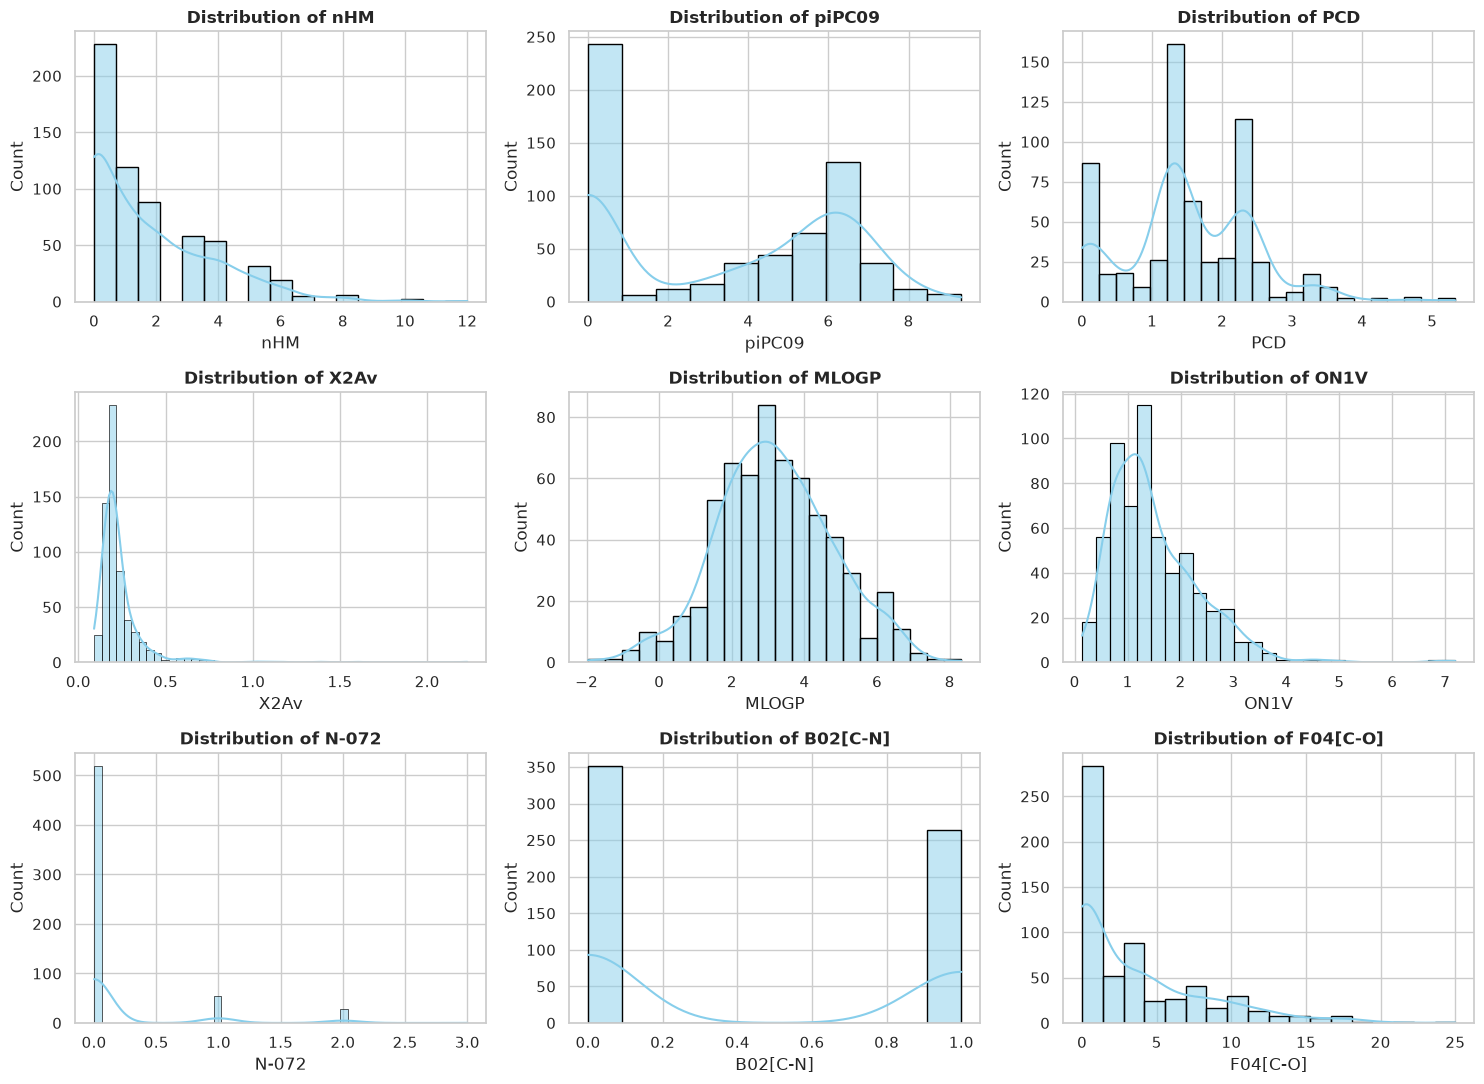

In [22]:
sns.set_theme(style="whitegrid")

# Select only the predictor features
feature_cols = [c for c in X_train_imputed.columns]

# Create a grid of subplots (3x3 grid for 9 features)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 11))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    sns.histplot(
        data=train,
        x=col,
        kde=True,
        ax=axes[idx],
        color="skyblue",
        edgecolor="black"
    )
    axes[idx].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")

plt.tight_layout()
plt.show()

- nHM and ON1V are right-skewed
- piPC09, N-072, F04[C-O] zero-inflated
- B02[C-O] is binary 
- features are scaled differently

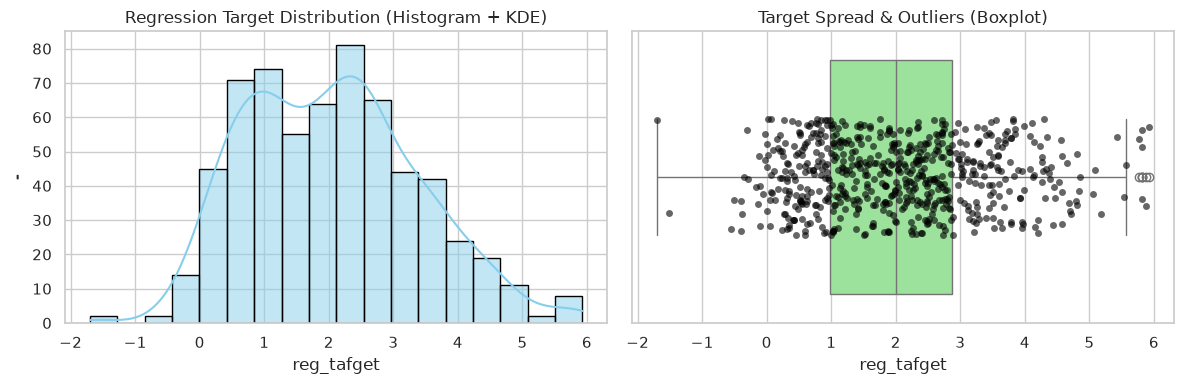

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Histogram + KDE
sns.histplot(reg_tafget, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Regression Target Distribution (Histogram + KDE)')
axes[0].set_xlabel('reg_tafget')
axes[0].set_ylabel('-')

# 2. Boxplot
sns.boxplot(x=reg_tafget, ax=axes[1], color='lightgreen')

# 2. Overlay the individual points
sns.stripplot(
    x=reg_tafget, 
    ax=axes[1], 
    color='black',    # Color of the points
    alpha=0.6,        # Transparency so overlapping points are visible
    jitter=0.2        # Spreads points horizontally to avoid overlapping into a single line
)

axes[1].set_title('Target Spread & Outliers (Boxplot)')
axes[1].set_xlabel('reg_tafget')

plt.tight_layout()
plt.show()


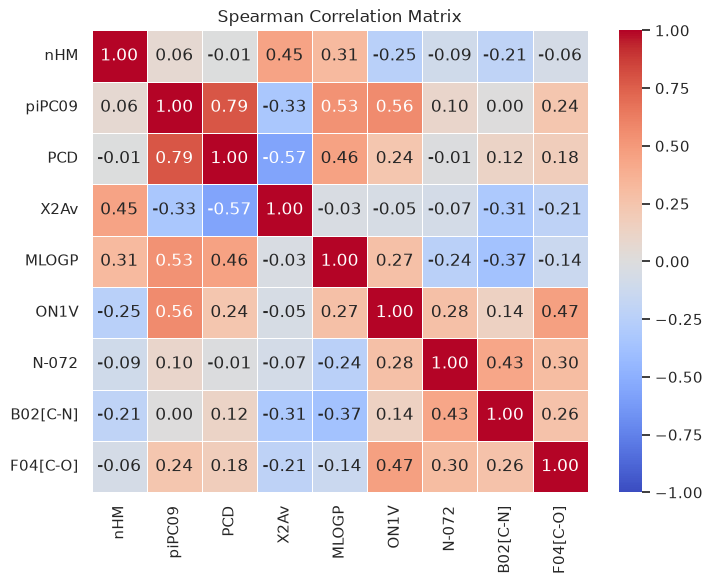

In [27]:
spearman_corr = X_train_imputed.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,  # Displays the correlation coefficient value inside each cell
    cmap='coolwarm',  # Color map (blue = negative, red = positive)
    fmt='.2f',  # Format numbers to 2 decimal places
    vmin=-1,
    vmax=1,  # Fixes the color scale from -1 to 1
    linewidths=0.5,  # Adds grid lines between cells
)

plt.title('Spearman Correlation Matrix')
plt.show()

In [28]:
spearman_corr

,nHM,piPC09,PCD,X2Av,MLOGP,ON1V,N-072,B02[C-N],F04[C-O]
nHM,1.000000,0.064784,-0.005095,0.451911,0.313920,-0.247832,-0.094992,-0.209551,-0.062880
piPC09,0.064784,1.000000,0.787201,-0.334986,0.531414,0.563837,0.099658,0.002996,0.236439
PCD,-0.005095,0.787201,1.000000,-0.567991,0.459568,0.238050,-0.009423,0.124413,0.179571
X2Av,0.451911,-0.334986,-0.567991,1.000000,-0.033767,-0.049843,-0.073499,-0.313347,-0.211921
MLOGP,0.313920,0.531414,0.459568,-0.033767,1.000000,0.273543,-0.240369,-0.367307,-0.139091
ON1V,-0.247832,0.563837,0.238050,-0.049843,0.273543,1.000000,0.277819,0.141897,0.466437
N-072,-0.094992,0.099658,-0.009423,-0.073499,-0.240369,0.277819,1.000000,0.430895,0.297237
B02[C-N],-0.209551,0.002996,0.124413,-0.313347,-0.367307,0.141897,0.430895,1.000000,0.262339
F04[C-O],-0.062880,0.236439,0.179571,-0.211921,-0.139091,0.466437,0.297237,0.262339,1.000000


In [31]:
cls_target.value_counts()

classification_target
1    368
3    204
2     51
Name: count, dtype: int64

## Data preparation

In [40]:
import numpy as np
import pandas as pd

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import StandardScaler, SplineTransformer

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.pipeline import Pipeline

from sklearn.model_selection import KFold

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [41]:
cv_reg = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [43]:
def evaluate_regression_model(model, X, y, cv):

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X), start=1
    ):

        X_fold_train = X.iloc[train_idx]
        X_fold_val = X.iloc[val_idx]

        y_fold_train = y.iloc[train_idx]
        y_fold_val = y.iloc[val_idx]

        # Fit entire pipeline only on fold training data
        model.fit(X_fold_train, y_fold_train)

        # Predict validation fold
        y_pred = model.predict(X_fold_val)

        # Metrics
        mae = mean_absolute_error(
            y_fold_val,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                y_pred
            )
        )

        r2 = r2_score(
            y_fold_val,
            y_pred
        )

        fold_results.append({
            "fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    fold_results = pd.DataFrame(fold_results)

    summary = pd.DataFrame({
        "MAE_mean": [fold_results["MAE"].mean()],
        "MAE_std": [fold_results["MAE"].std()],
        "RMSE_mean": [fold_results["RMSE"].mean()],
        "RMSE_std": [fold_results["RMSE"].std()],
        "R2_mean": [fold_results["R2"].mean()],
        "R2_std": [fold_results["R2"].std()]
    })

    return fold_results, summary

In [42]:
linear_pipeline = Pipeline([
    ("imputer", IterativeImputer(
        random_state=RANDOM_STATE
    )),
    
    ("scaler", StandardScaler()),
    
    ("model", LinearRegression())
])

In [44]:
linear_folds, linear_summary = evaluate_regression_model(
    linear_pipeline,
    X_train,
    y_reg,
    cv_reg
)

In [45]:
linear_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,0.623189,0.022445,0.813151,0.043936,0.622048,0.035017


In [47]:
ridge_pipeline = Pipeline([
    ("imputer", IterativeImputer(
        random_state=RANDOM_STATE
    )),
    
    ("scaler", StandardScaler()),
    
    ("model", Ridge(alpha=1.0))
])

ridge_folds, ridge_summary = evaluate_regression_model(
    ridge_pipeline,
    X_train,
    y_reg,
    cv_reg
)

ridge_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,0.623218,0.022449,0.813032,0.043817,0.622168,0.034819


In [49]:
spline_ridge_pipeline = Pipeline([
    ("imputer", IterativeImputer(
        random_state=RANDOM_STATE
    )),
    
    ("spline", SplineTransformer(
        n_knots=5,
        degree=3,
        include_bias=False
    )),
    
    ("scaler", StandardScaler()),
    
    ("model", Ridge(alpha=1.0))
])

spline_ridge_folds, spline_ridge_summary = evaluate_regression_model(
    spline_ridge_pipeline,
    X_train,
    y_reg,
    cv_reg
)

spline_ridge_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,0.592336,0.037411,0.773855,0.065615,0.655602,0.0606


In [50]:
comparison = pd.concat(
    [
        linear_summary.assign(model="Linear Regression"),
        ridge_summary.assign(model="Ridge Regression"),
        spline_ridge_summary.assign(model="Spline + Ridge")
    ],
    ignore_index=True
)

comparison = comparison[
    [
        "model",
        "MAE_mean",
        "MAE_std",
        "RMSE_mean",
        "RMSE_std",
        "R2_mean",
        "R2_std"
    ]
]

display(comparison)

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Linear Regression,0.623189,0.022445,0.813151,0.043936,0.622048,0.035017
1,Ridge Regression,0.623218,0.022449,0.813032,0.043817,0.622168,0.034819
2,Spline + Ridge,0.592336,0.037411,0.773855,0.065615,0.655602,0.060600


In [51]:
display(spline_ridge_folds)

,fold,MAE,RMSE,R2
0,1,0.532534,0.663721,0.745277
1,2,0.598034,0.805604,0.657570
2,3,0.603164,0.783304,0.587643
3,4,0.592343,0.779880,0.673298
4,5,0.635607,0.836767,0.614221


In [53]:
display(linear_folds)

,fold,MAE,RMSE,R2
0,1,0.606293,0.802150,0.627944
1,2,0.632080,0.826571,0.639514
2,3,0.597124,0.765670,0.606000
3,4,0.626244,0.790129,0.664654
4,5,0.654204,0.881238,0.572126


Improve spline + ridge

In [54]:
def evaluate_spline_ridge_configs(
    X,
    y,
    cv,
    n_knots_values,
    degree_values,
    alpha_values
):

    results = []

    for n_knots in n_knots_values:

        for degree in degree_values:

            for alpha in alpha_values:

                model = Pipeline([
                    (
                        "imputer",
                        IterativeImputer(
                            random_state=RANDOM_STATE
                        )
                    ),

                    (
                        "spline",
                        SplineTransformer(
                            n_knots=n_knots,
                            degree=degree,
                            include_bias=False
                        )
                    ),

                    (
                        "scaler",
                        StandardScaler()
                    ),

                    (
                        "model",
                        Ridge(alpha=alpha)
                    )
                ])

                fold_results = []

                for train_idx, val_idx in cv.split(X):

                    X_fold_train = X.iloc[train_idx]
                    X_fold_val = X.iloc[val_idx]

                    y_fold_train = y.iloc[train_idx]
                    y_fold_val = y.iloc[val_idx]

                    model.fit(
                        X_fold_train,
                        y_fold_train
                    )

                    y_pred = model.predict(
                        X_fold_val
                    )

                    mae = mean_absolute_error(
                        y_fold_val,
                        y_pred
                    )

                    rmse = np.sqrt(
                        mean_squared_error(
                            y_fold_val,
                            y_pred
                        )
                    )

                    r2 = r2_score(
                        y_fold_val,
                        y_pred
                    )

                    fold_results.append({
                        "MAE": mae,
                        "RMSE": rmse,
                        "R2": r2
                    })

                fold_df = pd.DataFrame(fold_results)

                results.append({
                    "n_knots": n_knots,
                    "degree": degree,
                    "alpha": alpha,

                    "MAE_mean": fold_df["MAE"].mean(),
                    "MAE_std": fold_df["MAE"].std(),

                    "RMSE_mean": fold_df["RMSE"].mean(),
                    "RMSE_std": fold_df["RMSE"].std(),

                    "R2_mean": fold_df["R2"].mean(),
                    "R2_std": fold_df["R2"].std()
                })

    return pd.DataFrame(results)

In [55]:
spline_tuning_results = evaluate_spline_ridge_configs(
    X_train,
    y_reg,
    cv_reg,

    n_knots_values=[4, 5, 7],
    degree_values=[2, 3],
    alpha_values=[0.01, 0.1, 1, 10, 100]
)

display(spline_tuning_results)

,n_knots,degree,alpha,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,4,2,0.01,0.595614,0.032175,0.784817,0.047144,0.647257,0.042734
1,4,2,0.10,0.596037,0.033713,0.783348,0.050228,0.648408,0.045555
2,4,2,1.00,0.595024,0.039570,0.778328,0.058566,0.652473,0.052196
3,4,2,10.00,0.596171,0.039283,0.776636,0.061523,0.654149,0.052081
4,4,2,100.00,0.601398,0.039431,0.779075,0.063067,0.652810,0.046026
5,4,3,0.01,0.604451,0.036156,0.792009,0.066395,0.640295,0.055282
6,4,3,0.10,0.597411,0.034576,0.780509,0.060338,0.650632,0.051827
7,4,3,1.00,0.596702,0.034499,0.781961,0.055429,0.649496,0.048619
8,4,3,10.00,0.594116,0.034747,0.778071,0.056304,0.652881,0.049432
9,4,3,100.00,0.593570,0.036089,0.774726,0.055425,0.656373,0.044180


In [56]:
best_spline_models = spline_tuning_results.sort_values(
    "RMSE_mean"
).head(10)

display(best_spline_models)

,n_knots,degree,alpha,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
19,5,3,100.0,0.590049,0.038522,0.771851,0.056232,0.658712,0.046206
18,5,3,10.0,0.589657,0.033306,0.772143,0.058649,0.657685,0.053775
17,5,3,1.0,0.592336,0.037411,0.773855,0.065615,0.655602,0.060600
29,7,3,100.0,0.589433,0.035431,0.773987,0.057844,0.656727,0.047844
9,4,3,100.0,0.593570,0.036089,0.774726,0.055425,0.656373,0.044180
3,4,2,10.0,0.596171,0.039283,0.776636,0.061523,0.654149,0.052081
8,4,3,10.0,0.594116,0.034747,0.778071,0.056304,0.652881,0.049432
2,4,2,1.0,0.595024,0.039570,0.778328,0.058566,0.652473,0.052196
16,5,3,0.1,0.596030,0.035245,0.778396,0.061427,0.651478,0.060661
14,5,2,100.0,0.596458,0.037088,0.778521,0.064272,0.652860,0.050614


In [57]:
best_r2_models = spline_tuning_results.sort_values(
    "R2_mean",
    ascending=False
).head(10)

display(best_r2_models)

,n_knots,degree,alpha,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
19,5,3,100.0,0.590049,0.038522,0.771851,0.056232,0.658712,0.046206
18,5,3,10.0,0.589657,0.033306,0.772143,0.058649,0.657685,0.053775
29,7,3,100.0,0.589433,0.035431,0.773987,0.057844,0.656727,0.047844
9,4,3,100.0,0.593570,0.036089,0.774726,0.055425,0.656373,0.044180
17,5,3,1.0,0.592336,0.037411,0.773855,0.065615,0.655602,0.060600
3,4,2,10.0,0.596171,0.039283,0.776636,0.061523,0.654149,0.052081
8,4,3,10.0,0.594116,0.034747,0.778071,0.056304,0.652881,0.049432
14,5,2,100.0,0.596458,0.037088,0.778521,0.064272,0.652860,0.050614
4,4,2,100.0,0.601398,0.039431,0.779075,0.063067,0.652810,0.046026
2,4,2,1.0,0.595024,0.039570,0.778328,0.058566,0.652473,0.052196


In [58]:
def evaluate_model(model, X, y, cv):
    
    results = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X), start=1):

        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)

        y_pred = model.predict(X_val_fold).ravel()

        results.append({
            "fold": fold,
            "MAE": mean_absolute_error(y_val_fold, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_val_fold, y_pred)),
            "R2": r2_score(y_val_fold, y_pred)
        })

    results = pd.DataFrame(results)

    summary = {
        "MAE_mean": results["MAE"].mean(),
        "MAE_std": results["MAE"].std(),
        "RMSE_mean": results["RMSE"].mean(),
        "RMSE_std": results["RMSE"].std(),
        "R2_mean": results["R2"].mean(),
        "R2_std": results["R2"].std()
    }

    return results, summary

In [59]:
from sklearn.decomposition import PCA
from sklearn.linear_model import HuberRegressor
from sklearn.cross_decomposition import PLSRegression

In [60]:
models = {

    "Linear": Pipeline([
        ("imputer", IterativeImputer(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("imputer", IterativeImputer(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Spline_Ridge": Pipeline([
        ("imputer", IterativeImputer(random_state=RANDOM_STATE)),
        ("spline", SplineTransformer(
            n_knots=5,
            degree=3,
            include_bias=False
        )),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=100))
    ]),

    "PLSR": Pipeline([
        ("imputer", IterativeImputer(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=2))
    ]),

    "PCR": Pipeline([
        ("imputer", IterativeImputer(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2)),
        ("model", LinearRegression())
    ]),

    "Huber": Pipeline([
        ("imputer", IterativeImputer(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("model", HuberRegressor())
    ])
}

In [61]:
all_results = []

for name, model in models.items():

    _, summary = evaluate_model(
        model,
        X_train,
        y_reg,
        cv_reg
    )

    summary["model"] = name
    all_results.append(summary)

comparison = pd.DataFrame(all_results)

comparison.sort_values("RMSE_mean")

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,model
2,0.590049,0.038522,0.771851,0.056232,0.658712,0.046206,Spline_Ridge
1,0.623218,0.022449,0.813032,0.043817,0.622168,0.034819,Ridge
0,0.623189,0.022445,0.813151,0.043936,0.622048,0.035017,Linear
5,0.613411,0.024202,0.818136,0.040864,0.617303,0.034390,Huber
3,0.639954,0.022251,0.826570,0.032870,0.609130,0.034890,PLSR
4,0.686849,0.036351,0.874149,0.042682,0.562408,0.048095,PCR


In [ ]:
# Polynomial + Ridge
from sklearn.preprocessing import PolynomialFeatures

poly_results = []

for degree in [2, 3]:
    for alpha in [0.01, 0.1, 1, 10, 100]:

        model = Pipeline([
            ("imputer", IterativeImputer(random_state=RANDOM_STATE)),
            ("scaler", StandardScaler()),
            ("polynomial", PolynomialFeatures(
                degree=degree,
                include_bias=False
            )),
            ("poly_scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha))
        ])

        _, summary = evaluate_model(
            model,
            X_train,
            y_reg,
            cv_reg
        )

        summary["degree"] = degree
        summary["alpha"] = alpha

        poly_results.append(summary)

poly_results = pd.DataFrame(poly_results)

display(
    poly_results.sort_values("RMSE_mean")
)

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,degree,alpha
3,0.592030,0.048653,0.785098,0.066107,0.646113,0.057412,2,10.00
4,0.604459,0.035699,0.785137,0.047233,0.646435,0.048192,2,100.00
9,0.590913,0.045227,0.796976,0.083564,0.634571,0.072986,3,100.00
2,0.601302,0.052539,0.798864,0.074372,0.633602,0.062180,2,1.00
1,0.603893,0.053370,0.803340,0.076752,0.629532,0.063528,2,0.10
0,0.604215,0.053461,0.803912,0.077067,0.629010,0.063712,2,0.01
8,0.618785,0.048424,0.942140,0.195313,0.479196,0.222091,3,10.00
7,0.758746,0.105357,1.326571,0.549863,-0.133355,1.011983,3,1.00
6,0.995063,0.255703,2.322639,1.798146,-3.460694,6.936151,3,0.10
5,1.221077,0.401766,3.449882,3.000646,-9.592343,17.169460,3,0.01


In [63]:
spline_results = []

for n_knots in [3, 4, 5, 6, 7, 8, 10]:
    for degree in [2, 3]:
        for alpha in [1, 10, 30, 100, 300, 1000]:

            model = Pipeline([
                ("imputer", IterativeImputer(
                    random_state=RANDOM_STATE
                )),
                ("spline", SplineTransformer(
                    n_knots=n_knots,
                    degree=degree,
                    include_bias=False
                )),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=alpha))
            ])

            _, summary = evaluate_model(
                model,
                X_train,
                y_reg,
                cv_reg
            )

            summary["n_knots"] = n_knots
            summary["degree"] = degree
            summary["alpha"] = alpha

            spline_results.append(summary)

spline_results = pd.DataFrame(spline_results)

display(
    spline_results
    .sort_values("RMSE_mean")
    .head(15)
)

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,n_knots,degree,alpha
45,0.586900,0.037411,0.770073,0.057941,0.660268,0.047171,6,3,100
32,0.587988,0.033808,0.771032,0.055434,0.659031,0.049448,5,3,30
33,0.590049,0.038522,0.771851,0.056232,0.658712,0.046206,5,3,100
31,0.589657,0.033306,0.772143,0.058649,0.657685,0.053775,5,3,10
7,0.591743,0.034157,0.773390,0.051363,0.657273,0.045146,3,3,10
30,0.592336,0.037411,0.773855,0.065615,0.655602,0.060600,5,3,1
57,0.589433,0.035431,0.773987,0.057844,0.656727,0.047844,7,3,100
6,0.592151,0.035954,0.774477,0.052969,0.655890,0.049806,3,3,1
21,0.593570,0.036089,0.774726,0.055425,0.656373,0.044180,4,3,100
20,0.592402,0.035482,0.774750,0.056655,0.655922,0.048526,4,3,30


Spline + Ridge: 6 knots, degree 3, α=100

In [65]:
final_regression_model = Pipeline([
    ("imputer", IterativeImputer(
        random_state=RANDOM_STATE
    )),
    ("spline", SplineTransformer(
        n_knots=6,
        degree=3,
        include_bias=False
    )),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=100))
])

final_regression_model.fit(
    X_train,
    y_reg
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('spline', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['nHM','piPC09','PCD',...,'N-072','B02[C-N]','F04[C-O]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"random_state random_state: int, RandomState instance or None, default=NoneThe seed of the pseudo random number generator to use. Randomizesselection of estimator features if `n_nearest_features` is not `None`,the `imputation_order` if `random`, and the sampling from posterior if`sample_posterior=True`. Use an integer for determinism.See :term:`the Glossary <random_state>`.",280926
,"estimator estimator: estimator object, default=BayesianRidge()The estimator to use at each step of the round-robin imputation.If `sample_posterior=True`, the estimator must support`return_std` in its `predict` method.",None
,"missing_values missing_values: int or np.nan, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to `np.nan`, since `pd.NA` will be converted to `np.nan`.",nan
,"sample_posterior sample_posterior: bool, default=FalseWhether to sample from the (Gaussian) predictive posterior of thefitted estimator for each imputation. Estimator must support`return_std` in its `predict` method if set to `True`. Set to`True` if using `IterativeImputer` for multiple imputations.",False


In [66]:
regression_predictions = final_regression_model.predict(
    X_test
).ravel()

In [67]:
pd.Series(regression_predictions).describe()

count    156.000000
mean       2.137578
std        1.135745
min       -0.357135
25%        1.258841
50%        2.050413
75%        2.907636
max        4.682168
dtype: float64

In [68]:
reg_submission = pd.DataFrame({
    "sample_id": test["sample_id"],
    "regression_prediction": regression_predictions
})

reg_submission.head(5)

,sample_id,regression_prediction
0,78-79-5,0.861837
1,16606-02-3,3.797140
2,111-44-4,0.776910
3,107-05-1,0.505505
4,555-03-3,0.682408


In [69]:
reg_submission.to_csv('reg_submission.csv')

## Classification

In [70]:
y_cls.value_counts()

classification_target
1    368
3    204
2     51
Name: count, dtype: int64

In [71]:
y_cls.value_counts(normalize=True)

classification_target
1    0.590690
3    0.327448
2    0.081862
Name: proportion, dtype: float64

In [72]:
from sklearn.model_selection import StratifiedKFold

cv_cls = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [73]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [76]:
from sklearn.linear_model import LogisticRegression

classification_model = ImbPipeline([
    ("imputer", IterativeImputer(
        random_state=RANDOM_STATE
    )),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=5
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

In [78]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score
)

def evaluate_classification_model(model, X, y, cv):

    results = []

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y), start=1
    ):

        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]

        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        model.fit(
            X_train_fold,
            y_train_fold
        )

        y_pred = model.predict(X_val_fold)

        results.append({
            "fold": fold,
            "macro_F1": f1_score(
                y_val_fold,
                y_pred,
                average="macro"
            ),
            "weighted_F1": f1_score(
                y_val_fold,
                y_pred,
                average="weighted"
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_val_fold,
                y_pred
            ),
            "accuracy": accuracy_score(
                y_val_fold,
                y_pred
            )
        })

    results = pd.DataFrame(results)

    summary = {
        "macro_F1_mean": results["macro_F1"].mean(),
        "macro_F1_std": results["macro_F1"].std(),
        "weighted_F1_mean": results["weighted_F1"].mean(),
        "weighted_F1_std": results["weighted_F1"].std(),
        "balanced_accuracy_mean": results["balanced_accuracy"].mean(),
        "balanced_accuracy_std": results["balanced_accuracy"].std(),
        "accuracy_mean": results["accuracy"].mean(),
        "accuracy_std": results["accuracy"].std()
    }

    return results, summary

In [80]:
cls_folds, cls_summary = evaluate_classification_model(
    classification_model,
    X_train,
    y_cls,
    cv_cls
)

display(cls_folds)
display(pd.DataFrame([cls_summary]))

,fold,macro_F1,weighted_F1,balanced_accuracy,accuracy
0,1,0.442432,0.517981,0.539200,0.464000
1,2,0.439374,0.562991,0.455416,0.520000
2,3,0.396617,0.514913,0.397726,0.488000
3,4,0.465512,0.548415,0.543245,0.516129
4,5,0.507301,0.567110,0.622973,0.548387


,macro_F1_mean,macro_F1_std,weighted_F1_mean,weighted_F1_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std
0,0.450247,0.040446,0.542282,0.024609,0.511712,0.087021,0.507303,0.032306


In [83]:
from sklearn.metrics import classification_report, confusion_matrix

classification_model.fit(X_train, y_cls)

y_pred_train = classification_model.predict(X_train)

print(classification_report(y_cls, y_pred_train))

              precision    recall  f1-score   support

           1       0.76      0.55      0.64       368
           2       0.14      0.45      0.22        51
           3       0.59      0.56      0.58       204

    accuracy                           0.55       623
   macro avg       0.50      0.52      0.48       623
weighted avg       0.65      0.55      0.58       623



In [85]:
classification_models = {

    "Logistic": ImbPipeline([
        ("imputer", IterativeImputer(
            random_state=RANDOM_STATE
        )),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Logistic_balanced": ImbPipeline([
        ("imputer", IterativeImputer(
            random_state=RANDOM_STATE
        )),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Logistic_SMOTE": classification_model
}

In [86]:
classification_results = []

for name, model in classification_models.items():

    _, summary = evaluate_classification_model(
        model,
        X_train,
        y_cls,
        cv_cls
    )

    summary["model"] = name
    classification_results.append(summary)

classification_results = pd.DataFrame(
    classification_results
)

display(
    classification_results[
        [
            "model",
            "macro_F1_mean",
            "macro_F1_std",
            "weighted_F1_mean",
            "balanced_accuracy_mean",
            "accuracy_mean"
        ]
    ].sort_values("macro_F1_mean", ascending=False)
)

,model,macro_F1_mean,macro_F1_std,weighted_F1_mean,balanced_accuracy_mean,accuracy_mean
0,Logistic,0.475535,0.037852,0.642157,0.469438,0.680581
2,Logistic_SMOTE,0.450247,0.040446,0.542282,0.511712,0.507303
1,Logistic_balanced,0.445707,0.053284,0.547557,0.497116,0.512129


In [87]:
from sklearn.base import clone

oof_predictions = {}

for name, model in classification_models.items():

    y_pred_oof = np.empty(len(y_cls), dtype=y_cls.dtype)

    for train_idx, val_idx in cv_cls.split(X_train, y_cls):

        model_fold = clone(model)

        model_fold.fit(
            X_train.iloc[train_idx],
            y_cls.iloc[train_idx]
        )

        y_pred_oof[val_idx] = model_fold.predict(
            X_train.iloc[val_idx]
        )

    oof_predictions[name] = y_pred_oof

In [88]:
from sklearn.metrics import classification_report

for name, y_pred in oof_predictions.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_cls,
            y_pred,
            digits=3
        )
    )

Logistic
              precision    recall  f1-score   support

           1      0.689     0.905     0.783       368
           2      0.444     0.078     0.133        51
           3      0.664     0.426     0.519       204

    accuracy                          0.681       623
   macro avg      0.599     0.470     0.478       623
weighted avg      0.661     0.681     0.643       623

Logistic_balanced
              precision    recall  f1-score   support

           1      0.732     0.519     0.607       368
           2      0.132     0.451     0.204        51
           3      0.559     0.515     0.536       204

    accuracy                          0.512       623
   macro avg      0.474     0.495     0.449       623
weighted avg      0.626     0.512     0.551       623

Logistic_SMOTE
              precision    recall  f1-score   support

           1      0.727     0.484     0.581       368
           2      0.139     0.490     0.216        51
           3      0.571     0.554

In [90]:
for name, y_pred in oof_predictions.items():

    print("\n", name)

    print(
        pd.Series(y_pred)
        .value_counts()
        .sort_index()
    )


 Logistic
1    483
2      9
3    131
Name: count, dtype: int64

 Logistic_balanced
1    261
2    174
3    188
Name: count, dtype: int64

 Logistic_SMOTE
1    245
2    180
3    198
Name: count, dtype: int64


Class 2 looks like very problemaitic even with SMOTE. Do these classes seperate on PCA?

In [91]:
# Impute missing values
imputer = IterativeImputer(
    random_state=RANDOM_STATE
)

X_imputed = imputer.fit_transform(X_train)

# Standardize features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.28702259 0.23283673]
Total explained variance:
0.5198593186751936


In [ ]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "class": y_cls.values
})

pca_df.head()

,PC1,PC2,class
0,1.141763,3.655571,3
1,-1.360816,-0.784552,3
2,-1.430087,0.604953,1
3,-1.829762,0.137832,1
4,0.674120,0.944923,1


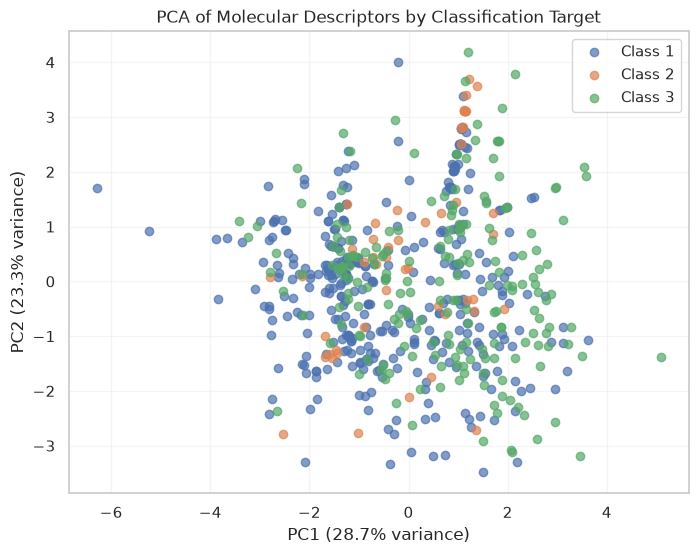

In [93]:
plt.figure(figsize=(8, 6))

for cls in sorted(pca_df["class"].unique()):
    
    subset = pca_df[pca_df["class"] == cls]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Class {cls}",
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA of Molecular Descriptors by Classification Target")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [94]:
pca_all = PCA()

X_pca_all = pca_all.fit_transform(X_scaled)

explained = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(pca_all.explained_variance_ratio_) + 1)],
    "explained_variance": pca_all.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_all.explained_variance_ratio_)
})

explained

,PC,explained_variance,cumulative_variance
0,PC1,0.287023,0.287023
1,PC2,0.232837,0.519859
2,PC3,0.148709,0.668568
3,PC4,0.109281,0.777849
4,PC5,0.072571,0.850420
5,PC6,0.062223,0.912643
6,PC7,0.051238,0.963881
7,PC8,0.024225,0.988106
8,PC9,0.011894,1.000000


In [96]:
from sklearn.model_selection import cross_val_score
pca_classification_results = []

for n_components in range(1, 10):

    pca = PCA(n_components=n_components)

    X_pca_n = pca.fit_transform(X_scaled)

    scores = cross_val_score(
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),
        X_pca_n,
        y_cls,
        cv=cv_cls,
        scoring="f1_macro"
    )

    pca_classification_results.append({
        "n_components": n_components,
        "variance_explained": pca.explained_variance_ratio_.sum(),
        "macro_F1_mean": scores.mean(),
        "macro_F1_std": scores.std()
    })

pca_classification_results = pd.DataFrame(
    pca_classification_results
)

pca_classification_results

,n_components,variance_explained,macro_F1_mean,macro_F1_std
0,1,0.287023,0.392100,0.017496
1,2,0.519859,0.384192,0.023477
2,3,0.668568,0.408110,0.023425
3,4,0.777849,0.403960,0.031874
4,5,0.850420,0.395433,0.042107
5,6,0.912643,0.400552,0.040482
6,7,0.963881,0.426866,0.017884
7,8,0.988106,0.429944,0.017543
8,9,1.000000,0.478136,0.036237


In [98]:
class_feature_stats = X_train.copy()
class_feature_stats["class"] = y_cls.values

class_feature_stats.groupby("class").mean().T

class,1,2,3
nHM,1.687845,2.224490,1.761194
piPC09,2.810094,3.837902,4.213569
PCD,1.460907,1.345800,1.709208
X2Av,0.243878,0.230400,0.224900
MLOGP,2.922348,3.879216,3.502690
ON1V,1.274832,1.526400,1.884478
N-072,0.187675,0.080000,0.218274
B02[C-N],0.476839,0.280000,0.376884
F04[C-O],2.696629,2.877551,5.361386


nHM and MLOGP are higher in class 2

In [99]:
class_feature_stats.groupby("class").std().T

class,1,2,3
nHM,1.796986,2.600203,2.152368
piPC09,2.970941,2.628231,2.835819
PCD,0.869011,0.920889,1.025719
X2Av,0.179623,0.190177,0.087775
MLOGP,1.549024,2.298015,1.297860
ON1V,0.638769,1.021960,0.997003
N-072,0.509532,0.274048,0.542172
B02[C-N],0.500145,0.453557,0.485828
F04[C-O],3.717956,3.497813,5.365552


nHM and MLOGP are higher in class 2. N-072 is lower

In [101]:
# Supervised Clistering
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(
    X_scaled,
    y_cls
)

lda_df = pd.DataFrame({
    "LD1": X_lda[:, 0],
    "LD2": X_lda[:, 1],
    "class": y_cls.values
})

lda_df.head()

,LD1,LD2,class
0,0.417733,-1.047386,3
1,-1.477314,0.318113,3
2,-0.547532,0.175482,1
3,-0.384437,-1.552337,1
4,-0.077152,-0.697228,1


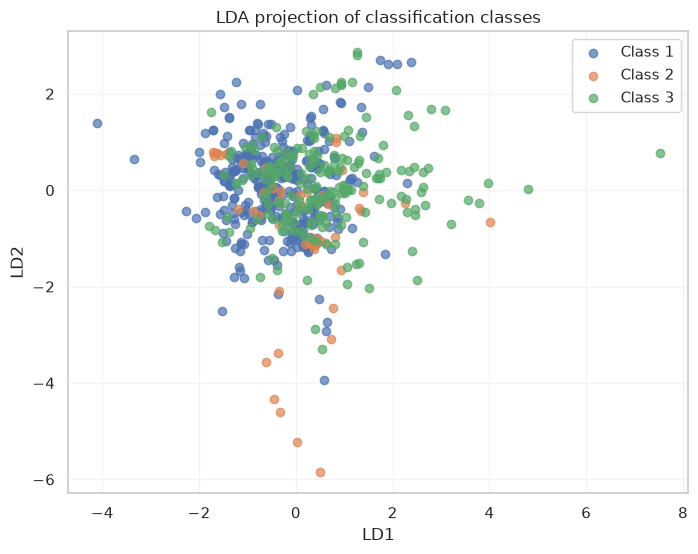

In [102]:
plt.figure(figsize=(8, 6))

for cls in sorted(lda_df["class"].unique()):

    subset = lda_df[lda_df["class"] == cls]

    plt.scatter(
        subset["LD1"],
        subset["LD2"],
        label=f"Class {cls}",
        alpha=0.7
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA projection of classification classes")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [103]:
lda_model = Pipeline([
    ("imputer", IterativeImputer(
        random_state=RANDOM_STATE
    )),
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

_, lda_summary = evaluate_classification_model(
    lda_model,
    X_train,
    y_cls,
    cv_cls
)

lda_summary

{'macro_F1_mean': np.float64(0.5018455481474657),
 'macro_F1_std': np.float64(0.07194222445108019),
 'weighted_F1_mean': np.float64(0.6384587431956615),
 'weighted_F1_std': np.float64(0.039102836528478166),
 'balanced_accuracy_mean': np.float64(0.4841728912644382),
 'balanced_accuracy_std': np.float64(0.05165409506403246),
 'accuracy_mean': np.float64(0.6774064516129032),
 'accuracy_std': np.float64(0.025574131701367214)}

In [107]:
## Moving theshold in logistic regression

from sklearn.base import clone

oof_probabilities = np.zeros(
    (len(y_cls), 3)
)

for train_idx, val_idx in cv_cls.split(X_train, y_cls):

    model_fold = clone(classification_models["Logistic"])

    model_fold.fit(
        X_train.iloc[train_idx],
        y_cls.iloc[train_idx]
    )

    oof_probabilities[val_idx] = model_fold.predict_proba(
        X_train.iloc[val_idx]
    )

class_labels = model_fold.classes_

print(class_labels)

def apply_class2_threshold(
    probabilities,
    class_labels,
    threshold
):
    
    adjusted = probabilities.copy()

    class2_idx = list(class_labels).index(2)

    adjusted[:, class2_idx] = (
        adjusted[:, class2_idx] / threshold
    )

    predictions = class_labels[
        np.argmax(adjusted, axis=1)
    ]

    return predictions

threshold_results = []

for threshold in [
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0,
    1.1,
    1.2,
    1.3,
    1.5,
    2.0
]:

    y_pred = apply_class2_threshold(
        oof_probabilities,
        class_labels,
        threshold
    )

    threshold_results.append({
        "class2_threshold": threshold,
        "macro_F1": f1_score(
            y_cls,
            y_pred,
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_cls,
            y_pred
        ),
        "accuracy": accuracy_score(
            y_cls,
            y_pred
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

[1 2 3]


,class2_threshold,macro_F1,balanced_accuracy,accuracy
0,0.5,0.517299,0.496075,0.686998
1,0.6,0.508792,0.489539,0.685393
2,0.7,0.509425,0.489539,0.685393
3,0.8,0.499345,0.483003,0.683788
4,0.9,0.488956,0.476467,0.682183
5,1.0,0.478448,0.469931,0.680578
6,1.1,0.478895,0.469931,0.680578
7,1.2,0.467875,0.463395,0.678973
8,1.3,0.456479,0.456859,0.677368
9,1.5,0.456382,0.456859,0.677368


lowering threshold helps

In [108]:
threshold_results_fine = []

for threshold in np.arange(0.20, 0.81, 0.05):

    y_pred = apply_class2_threshold(
        oof_probabilities,
        class_labels,
        threshold
    )

    threshold_results_fine.append({
        "class2_threshold": round(threshold, 2),
        "macro_F1": f1_score(
            y_cls,
            y_pred,
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_cls,
            y_pred
        ),
        "accuracy": accuracy_score(
            y_cls,
            y_pred
        )
    })

threshold_results_fine = pd.DataFrame(
    threshold_results_fine
)

threshold_results_fine

,class2_threshold,macro_F1,balanced_accuracy,accuracy
0,0.20,0.492560,0.520691,0.605136
1,0.25,0.518534,0.524634,0.646870
2,0.30,0.508372,0.499005,0.661316
3,0.35,0.520090,0.502984,0.675762
4,0.40,0.517581,0.497531,0.682183
5,0.45,0.523765,0.500977,0.686998
6,0.50,0.517299,0.496075,0.686998
7,0.55,0.518234,0.496075,0.686998
8,0.60,0.508792,0.489539,0.685393
9,0.65,0.508792,0.489539,0.685393


In [109]:
# Testing thesholds tuning with SMOTE

smote_oof_probabilities = np.zeros(
    (len(y_cls), 3)
)

for train_idx, val_idx in cv_cls.split(X_train, y_cls):

    model_fold = clone(
        classification_models["Logistic_SMOTE"]
    )

    model_fold.fit(
        X_train.iloc[train_idx],
        y_cls.iloc[train_idx]
    )

    smote_oof_probabilities[val_idx] = (
        model_fold.predict_proba(
            X_train.iloc[val_idx]
        )
    )

smote_class_labels = model_fold.classes_

In [110]:
smote_threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.05):

    y_pred = apply_class2_threshold(
        smote_oof_probabilities,
        smote_class_labels,
        threshold
    )

    smote_threshold_results.append({
        "class2_threshold": round(threshold, 2),
        "macro_F1": f1_score(
            y_cls,
            y_pred,
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_cls,
            y_pred
        ),
        "accuracy": accuracy_score(
            y_cls,
            y_pred
        )
    })

smote_threshold_results = pd.DataFrame(
    smote_threshold_results
)

smote_threshold_results

,class2_threshold,macro_F1,balanced_accuracy,accuracy
0,0.20,0.208050,0.400096,0.189406
1,0.25,0.234319,0.413878,0.213483
2,0.30,0.250400,0.420769,0.227929
3,0.35,0.267968,0.412759,0.247191
4,0.40,0.287072,0.412013,0.268058
5,0.45,0.323384,0.434836,0.314607
6,0.50,0.348879,0.442242,0.349920
7,0.55,0.372021,0.458369,0.382022
8,0.60,0.382942,0.455261,0.401284
9,0.65,0.394508,0.465224,0.418941


lowering class 2 treshold was not wise. now i will try to increase treshold on smote model

In [111]:
smote_threshold_results_extended = []

for threshold in np.arange(0.80, 1.51, 0.05):

    y_pred = apply_class2_threshold(
        smote_oof_probabilities,
        smote_class_labels,
        threshold
    )

    smote_threshold_results_extended.append({
        "class2_threshold": round(threshold, 2),
        "macro_F1": f1_score(
            y_cls,
            y_pred,
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_cls,
            y_pred
        ),
        "accuracy": accuracy_score(
            y_cls,
            y_pred
        )
    })

smote_threshold_results_extended = pd.DataFrame(
    smote_threshold_results_extended
)

smote_threshold_results_extended

,class2_threshold,macro_F1,balanced_accuracy,accuracy
0,0.80,0.428257,0.492061,0.467095
1,0.85,0.438833,0.503126,0.481541
2,0.90,0.443727,0.504387,0.491172
3,0.95,0.447639,0.504014,0.499197
4,1.00,0.453130,0.509271,0.507223
5,1.05,0.460252,0.511616,0.520064
6,1.10,0.462976,0.506518,0.529695
7,1.15,0.474137,0.516304,0.545746
8,1.20,0.477252,0.515203,0.553772
9,1.25,0.491061,0.526073,0.573034


Compare best simple logistic regression and with SMOTE (with tuned thesholds)

In [112]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score
)
import numpy as np
import pandas as pd


def nested_threshold_cv(
    model,
    X,
    y,
    outer_cv,
    inner_cv,
    thresholds
):
    
    outer_results = []
    selected_thresholds = []

    for outer_fold, (outer_train_idx, outer_val_idx) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):
        
        X_outer_train = X.iloc[outer_train_idx]
        X_outer_val = X.iloc[outer_val_idx]
        
        y_outer_train = y.iloc[outer_train_idx]
        y_outer_val = y.iloc[outer_val_idx]
        
        
        # --------------------------------------------------
        # 1. Generate inner OOF probabilities
        # --------------------------------------------------
        
        inner_probabilities = np.zeros(
            (len(X_outer_train), 3)
        )
        
        inner_class_labels = None
        
        for inner_train_idx, inner_val_idx in inner_cv.split(
            X_outer_train,
            y_outer_train
        ):
            
            model_inner = clone(model)
            
            model_inner.fit(
                X_outer_train.iloc[inner_train_idx],
                y_outer_train.iloc[inner_train_idx]
            )
            
            inner_probabilities[inner_val_idx] = (
                model_inner.predict_proba(
                    X_outer_train.iloc[inner_val_idx]
                )
            )
            
            inner_class_labels = model_inner.classes_
        
        
        # --------------------------------------------------
        # 2. Select threshold using ONLY inner OOF data
        # --------------------------------------------------
        
        threshold_scores = []
        
        for threshold in thresholds:
            
            y_inner_pred = apply_class2_threshold(
                inner_probabilities,
                inner_class_labels,
                threshold
            )
            
            threshold_scores.append({
                "threshold": threshold,
                "macro_F1": f1_score(
                    y_outer_train,
                    y_inner_pred,
                    average="macro"
                )
            })
        
        threshold_scores = pd.DataFrame(
            threshold_scores
        )
        
        best_threshold = threshold_scores.loc[
            threshold_scores["macro_F1"].idxmax(),
            "threshold"
        ]
        
        selected_thresholds.append(best_threshold)
        
        
        # --------------------------------------------------
        # 3. Fit model on ALL outer training data
        # --------------------------------------------------
        
        model_outer = clone(model)
        
        model_outer.fit(
            X_outer_train,
            y_outer_train
        )
        
        
        # --------------------------------------------------
        # 4. Predict outer validation probabilities
        # --------------------------------------------------
        
        outer_probabilities = model_outer.predict_proba(
            X_outer_val
        )
        
        outer_class_labels = model_outer.classes_
        
        
        # --------------------------------------------------
        # 5. Apply threshold selected WITHOUT outer fold
        # --------------------------------------------------
        
        y_outer_pred = apply_class2_threshold(
            outer_probabilities,
            outer_class_labels,
            best_threshold
        )
        
        
        # --------------------------------------------------
        # 6. Evaluate outer validation fold
        # --------------------------------------------------
        
        outer_results.append({
            "outer_fold": outer_fold,
            "selected_threshold": best_threshold,
            "macro_F1": f1_score(
                y_outer_val,
                y_outer_pred,
                average="macro"
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_outer_val,
                y_outer_pred
            ),
            "accuracy": accuracy_score(
                y_outer_val,
                y_outer_pred
            )
        })
    
    
    results = pd.DataFrame(outer_results)
    
    summary = {
        "macro_F1_mean": results["macro_F1"].mean(),
        "macro_F1_std": results["macro_F1"].std(),
        "balanced_accuracy_mean": results["balanced_accuracy"].mean(),
        "balanced_accuracy_std": results["balanced_accuracy"].std(),
        "accuracy_mean": results["accuracy"].mean(),
        "accuracy_std": results["accuracy"].std(),
        "threshold_mean": results["selected_threshold"].mean()
    }
    
    return results, summary

In [113]:
thresholds = np.arange(
    0.25,
    1.51,
    0.05
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 1
)

logistic_nested_results, logistic_nested_summary = (
    nested_threshold_cv(
        classification_models["Logistic"],
        X_train,
        y_cls,
        outer_cv,
        inner_cv,
        thresholds
    )
)

logistic_nested_results

,outer_fold,selected_threshold,macro_F1,balanced_accuracy,accuracy
0,1,0.30,0.525976,0.535443,0.656000
1,2,0.40,0.431669,0.435509,0.664000
2,3,0.30,0.444720,0.445838,0.616000
3,4,0.35,0.526327,0.506248,0.685484
4,5,0.40,0.590380,0.554279,0.693548


In [114]:
logistic_nested_summary

{'macro_F1_mean': np.float64(0.503814285997505),
 'macro_F1_std': np.float64(0.06555267494146773),
 'balanced_accuracy_mean': np.float64(0.49546337988202344),
 'balanced_accuracy_std': np.float64(0.052988641946088225),
 'accuracy_mean': np.float64(0.6630064516129032),
 'accuracy_std': np.float64(0.030404474176475592),
 'threshold_mean': np.float64(0.35)}

In [115]:
smote_nested_results, smote_nested_summary = (
    nested_threshold_cv(
        classification_models["Logistic_SMOTE"],
        X_train,
        y_cls,
        outer_cv,
        inner_cv,
        thresholds
    )
)

smote_nested_results

,outer_fold,selected_threshold,macro_F1,balanced_accuracy,accuracy
0,1,1.50,0.529287,0.554559,0.632000
1,2,1.15,0.456352,0.473434,0.552000
2,3,1.50,0.458785,0.458646,0.576000
3,4,1.45,0.504651,0.550006,0.572581
4,5,1.50,0.581824,0.606532,0.653226


In [116]:
smote_nested_summary

{'macro_F1_mean': np.float64(0.5061797410582851),
 'macro_F1_std': np.float64(0.052410426224684656),
 'balanced_accuracy_mean': np.float64(0.5286353758004276),
 'balanced_accuracy_std': np.float64(0.06152686839600122),
 'accuracy_mean': np.float64(0.5971612903225807),
 'accuracy_std': np.float64(0.04315239312318684),
 'threshold_mean': np.float64(1.42)}

In [118]:
# Simple logistic aprreared to be better

def nested_threshold_cv_predictions(
    model,
    X,
    y,
    outer_cv,
    inner_cv,
    thresholds
):
    
    outer_results = []
    all_predictions = np.empty(len(y), dtype=y.dtype)
    selected_thresholds = []

    for outer_fold, (outer_train_idx, outer_val_idx) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):
        
        X_outer_train = X.iloc[outer_train_idx]
        X_outer_val = X.iloc[outer_val_idx]
        
        y_outer_train = y.iloc[outer_train_idx]
        y_outer_val = y.iloc[outer_val_idx]
        
        # -----------------------------------------
        # Inner CV: select threshold
        # -----------------------------------------
        
        inner_probabilities = np.zeros(
            (len(X_outer_train), 3)
        )
        
        inner_class_labels = None
        
        for inner_train_idx, inner_val_idx in inner_cv.split(
            X_outer_train,
            y_outer_train
        ):
            
            model_inner = clone(model)
            
            model_inner.fit(
                X_outer_train.iloc[inner_train_idx],
                y_outer_train.iloc[inner_train_idx]
            )
            
            inner_probabilities[inner_val_idx] = (
                model_inner.predict_proba(
                    X_outer_train.iloc[inner_val_idx]
                )
            )
            
            inner_class_labels = model_inner.classes_
        
        # Select threshold using inner OOF predictions
        threshold_scores = []
        
        for threshold in thresholds:
            
            y_inner_pred = apply_class2_threshold(
                inner_probabilities,
                inner_class_labels,
                threshold
            )
            
            threshold_scores.append({
                "threshold": threshold,
                "macro_F1": f1_score(
                    y_outer_train,
                    y_inner_pred,
                    average="macro"
                )
            })
        
        threshold_scores = pd.DataFrame(
            threshold_scores
        )
        
        best_threshold = threshold_scores.loc[
            threshold_scores["macro_F1"].idxmax(),
            "threshold"
        ]
        
        selected_thresholds.append(best_threshold)
        
        # -----------------------------------------
        # Fit on complete outer training fold
        # -----------------------------------------
        
        model_outer = clone(model)
        
        model_outer.fit(
            X_outer_train,
            y_outer_train
        )
        
        # -----------------------------------------
        # Predict outer validation fold
        # -----------------------------------------
        
        outer_probabilities = model_outer.predict_proba(
            X_outer_val
        )
        
        outer_class_labels = model_outer.classes_
        
        y_outer_pred = apply_class2_threshold(
            outer_probabilities,
            outer_class_labels,
            best_threshold
        )
        
        # Store predictions in original row positions
        all_predictions[outer_val_idx] = y_outer_pred
        
        # Fold metrics
        outer_results.append({
            "outer_fold": outer_fold,
            "selected_threshold": best_threshold,
            "macro_F1": f1_score(
                y_outer_val,
                y_outer_pred,
                average="macro"
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_outer_val,
                y_outer_pred
            ),
            "accuracy": accuracy_score(
                y_outer_val,
                y_outer_pred
            )
        })
    
    results = pd.DataFrame(outer_results)
    
    return (
        results,
        all_predictions,
        selected_thresholds
    )

In [119]:
thresholds = np.arange(
    0.25,
    1.51,
    0.05
)

(
    logistic_results,
    logistic_outer_predictions,
    logistic_selected_thresholds
) = nested_threshold_cv_predictions(
    classification_models["Logistic"],
    X_train,
    y_cls,
    outer_cv,
    inner_cv,
    thresholds
)

logistic_results

,outer_fold,selected_threshold,macro_F1,balanced_accuracy,accuracy
0,1,0.30,0.525976,0.535443,0.656000
1,2,0.40,0.431669,0.435509,0.664000
2,3,0.30,0.444720,0.445838,0.616000
3,4,0.35,0.526327,0.506248,0.685484
4,5,0.40,0.590380,0.554279,0.693548


In [120]:
print(
    classification_report(
        y_cls,
        logistic_outer_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

           1      0.687     0.872     0.769       368
           2      0.297     0.216     0.250        51
           3      0.681     0.397     0.502       204

    accuracy                          0.663       623
   macro avg      0.555     0.495     0.507       623
weighted avg      0.653     0.663     0.639       623



In [121]:
cm = confusion_matrix(
    y_cls,
    logistic_outer_predictions,
    labels=[1, 2, 3]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3"]
)

cm_df

,Predicted 1,Predicted 2,Predicted 3
Actual 1,321,17,30
Actual 2,32,11,8
Actual 3,114,9,81


In [122]:
print("Actual class counts:")
print(y_cls.value_counts().sort_index())

print("\nPredicted class counts:")
print(
    pd.Series(
        logistic_outer_predictions
    ).value_counts().sort_index()
)

Actual class counts:
classification_target
1    368
2     51
3    204
Name: count, dtype: int64

Predicted class counts:
1    467
2     37
3    119
Name: count, dtype: int64


In [123]:
pd.Series(
    logistic_selected_thresholds,
    name="selected_threshold"
)

0    0.30
1    0.40
2    0.30
3    0.35
4    0.40
Name: selected_threshold, dtype: float64

Class 2 id now detected by the model better. But most Fasle negstive class 2 and 3 predictions fall into class 1. We can try to increase theshold for class 1 to increase recall for the rest classes

In [124]:
def apply_two_thresholds(
    probabilities,
    class_labels,
    class1_threshold=1.0,
    class2_threshold=0.35
):
    
    adjusted = probabilities.copy()

    class1_idx = list(class_labels).index(1)
    class2_idx = list(class_labels).index(2)

    adjusted[:, class1_idx] = (
        adjusted[:, class1_idx] / class1_threshold
    )

    adjusted[:, class2_idx] = (
        adjusted[:, class2_idx] / class2_threshold
    )

    predictions = class_labels[
        np.argmax(adjusted, axis=1)
    ]

    return predictions

In [125]:
class1_threshold=1.0
class2_threshold=0.35

In [126]:
def nested_class1_threshold_cv(
    model,
    X,
    y,
    outer_cv,
    inner_cv,
    class1_thresholds,
    class2_threshold=0.35
):
    
    outer_results = []
    all_predictions = np.empty(len(y), dtype=y.dtype)
    selected_thresholds = []

    for outer_fold, (outer_train_idx, outer_val_idx) in enumerate(
        outer_cv.split(X, y),
        start=1
    ):
        
        X_outer_train = X.iloc[outer_train_idx]
        X_outer_val = X.iloc[outer_val_idx]
        
        y_outer_train = y.iloc[outer_train_idx]
        y_outer_val = y.iloc[outer_val_idx]
        
        # -----------------------------------------
        # Inner OOF probabilities
        # -----------------------------------------
        
        inner_probabilities = np.zeros(
            (len(X_outer_train), 3)
        )
        
        inner_class_labels = None
        
        for inner_train_idx, inner_val_idx in inner_cv.split(
            X_outer_train,
            y_outer_train
        ):
            
            model_inner = clone(model)
            
            model_inner.fit(
                X_outer_train.iloc[inner_train_idx],
                y_outer_train.iloc[inner_train_idx]
            )
            
            inner_probabilities[inner_val_idx] = (
                model_inner.predict_proba(
                    X_outer_train.iloc[inner_val_idx]
                )
            )
            
            inner_class_labels = model_inner.classes_
        
        # -----------------------------------------
        # Tune class-1 threshold
        # Class-2 threshold stays at 0.35
        # -----------------------------------------
        
        threshold_scores = []
        
        for threshold1 in class1_thresholds:
            
            y_inner_pred = apply_two_thresholds(
                inner_probabilities,
                inner_class_labels,
                class1_threshold=threshold1,
                class2_threshold=class2_threshold
            )
            
            threshold_scores.append({
                "threshold1": threshold1,
                "macro_F1": f1_score(
                    y_outer_train,
                    y_inner_pred,
                    average="macro"
                )
            })
        
        threshold_scores = pd.DataFrame(
            threshold_scores
        )
        
        best_threshold1 = threshold_scores.loc[
            threshold_scores["macro_F1"].idxmax(),
            "threshold1"
        ]
        
        selected_thresholds.append(best_threshold1)
        
        # -----------------------------------------
        # Fit on complete outer training fold
        # -----------------------------------------
        
        model_outer = clone(model)
        
        model_outer.fit(
            X_outer_train,
            y_outer_train
        )
        
        # -----------------------------------------
        # Outer validation predictions
        # -----------------------------------------
        
        outer_probabilities = model_outer.predict_proba(
            X_outer_val
        )
        
        outer_class_labels = model_outer.classes_
        
        y_outer_pred = apply_two_thresholds(
            outer_probabilities,
            outer_class_labels,
            class1_threshold=best_threshold1,
            class2_threshold=class2_threshold
        )
        
        all_predictions[outer_val_idx] = y_outer_pred
        
        outer_results.append({
            "outer_fold": outer_fold,
            "class1_threshold": best_threshold1,
            "class2_threshold": class2_threshold,
            "macro_F1": f1_score(
                y_outer_val,
                y_outer_pred,
                average="macro"
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_outer_val,
                y_outer_pred
            ),
            "accuracy": accuracy_score(
                y_outer_val,
                y_outer_pred
            )
        })
    
    results = pd.DataFrame(outer_results)
    
    summary = {
        "macro_F1_mean": results["macro_F1"].mean(),
        "macro_F1_std": results["macro_F1"].std(),
        "balanced_accuracy_mean": results["balanced_accuracy"].mean(),
        "balanced_accuracy_std": results["balanced_accuracy"].std(),
        "accuracy_mean": results["accuracy"].mean(),
        "accuracy_std": results["accuracy"].std(),
        "class1_threshold_mean": results["class1_threshold"].mean()
    }
    
    return (
        results,
        summary,
        all_predictions,
        selected_thresholds
    )

In [127]:
class1_thresholds = np.arange(
    1.00,
    2.01,
    0.10
)

In [128]:
(
    class1_results,
    class1_summary,
    class1_outer_predictions,
    class1_selected_thresholds
) = nested_class1_threshold_cv(
    classification_models["Logistic"],
    X_train,
    y_cls,
    outer_cv,
    inner_cv,
    class1_thresholds,
    class2_threshold=0.35
)

class1_results

,outer_fold,class1_threshold,class2_threshold,macro_F1,balanced_accuracy,accuracy
0,1,1.2,0.35,0.551849,0.554450,0.664000
1,2,1.2,0.35,0.526852,0.516678,0.680000
2,3,1.2,0.35,0.436663,0.435704,0.592000
3,4,1.5,0.35,0.546980,0.579408,0.637097
4,5,1.3,0.35,0.581517,0.576577,0.685484


In [129]:
class1_summary

{'macro_F1_mean': np.float64(0.5287720223261954),
 'macro_F1_std': np.float64(0.055076896226320206),
 'balanced_accuracy_mean': np.float64(0.5325629635953726),
 'balanced_accuracy_std': np.float64(0.05967564352290868),
 'accuracy_mean': np.float64(0.6517161290322581),
 'accuracy_std': np.float64(0.03831081061786231),
 'class1_threshold_mean': np.float64(1.2800000000000005)}

In [130]:
print(
    classification_report(
        y_cls,
        class1_outer_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

           1      0.717     0.785     0.750       368
           2      0.286     0.314     0.299        51
           3      0.616     0.495     0.549       204

    accuracy                          0.652       623
   macro avg      0.540     0.531     0.533       623
weighted avg      0.649     0.652     0.647       623



In [131]:
cm = confusion_matrix(
    y_cls,
    class1_outer_predictions,
    labels=[1, 2, 3]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3"]
)

cm_df

,Predicted 1,Predicted 2,Predicted 3
Actual 1,289,26,53
Actual 2,25,16,10
Actual 3,89,14,101


In [132]:
print("Actual:")
print(y_cls.value_counts().sort_index())

print("\nPredicted:")
print(
    pd.Series(
        class1_outer_predictions
    ).value_counts().sort_index()
)

Actual:
classification_target
1    368
2     51
3    204
Name: count, dtype: int64

Predicted:
1    403
2     56
3    164
Name: count, dtype: int64


Applying best thresholds

In [133]:
final_classification_model = classification_models["Logistic"]

final_classification_model.fit(
    X_train,
    y_cls
)

test_probabilities = final_classification_model.predict_proba(
    X_test
)

test_class_labels = final_classification_model.classes_

test_probabilities[:5]

array([[0.78607934, 0.0924473 , 0.12147336],
       [0.57148107, 0.13493157, 0.29358736],
       [0.75723633, 0.10226903, 0.14049464],
       [0.84249264, 0.08179544, 0.07571192],
       [0.78868571, 0.0331741 , 0.17814019]])

In [135]:
final_classification_predictions = apply_two_thresholds(
    test_probabilities,
    test_class_labels,
    class1_threshold=1.30,
    class2_threshold=0.35
)

In [136]:
pd.Series(
    final_classification_predictions
).value_counts().sort_index()

1    90
2    16
3    50
Name: count, dtype: int64

In [137]:
pd.Series(
    final_classification_predictions
).value_counts(
    normalize=True
).sort_index()

1    0.576923
2    0.102564
3    0.320513
Name: proportion, dtype: float64

In [138]:
submission = pd.DataFrame({
    "sample_id": test["sample_id"],
    "regression_prediction": regression_predictions,
    "classification_prediction": final_classification_predictions
})

submission.head()

,sample_id,regression_prediction,classification_prediction
0,78-79-5,0.861837,1
1,16606-02-3,3.797140,1
2,111-44-4,0.776910,1
3,107-05-1,0.505505,1
4,555-03-3,0.682408,1


In [139]:
submission.to_csv('submission1.csv', index=False)